Device: cuda


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/3]  Loss=0.6446  TrainAcc=76.65%
Epoch [2/3]  Loss=0.5628  TrainAcc=79.10%
Epoch [3/3]  Loss=0.5458  TrainAcc=79.49%
✅ Training complete (Only ImageNet Weights).

=== Ablation Study 2: Only ImageNet Weights ===
                precision    recall  f1-score   support

        Cavity     0.2000    0.0455    0.0741        22
      Fillings     0.7288    0.6825    0.7049       315
Impacted Tooth     0.5357    0.4688    0.5000        32
       Implant     0.7207    0.7692    0.7442       104
        Normal     0.9033    0.9294    0.9162      1176

      accuracy                         0.8514      1649
     macro avg     0.6177    0.5791    0.5879      1649
  weighted avg     0.8419    0.8514    0.8457      1649



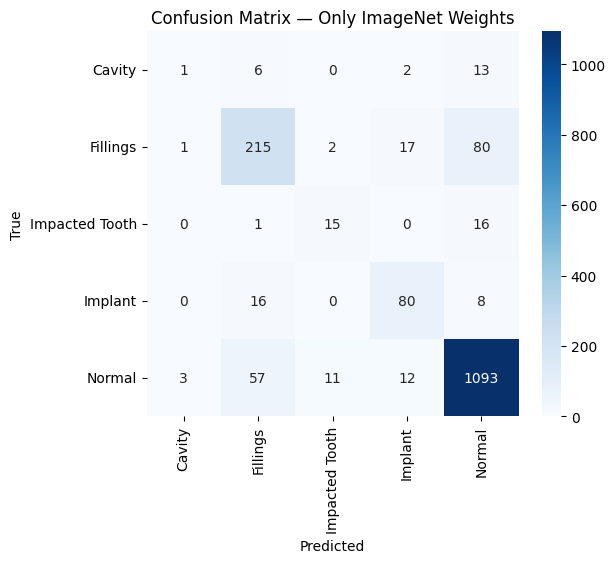


Overall Test Accuracy: 0.8514 - Only ImageNet Weights


In [10]:
# ==============================
# Ablation Study 2 — Only ImageNet Weights
# ==============================

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision.models as models
from torchvision import transforms, datasets
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ------------------------------
# 1️⃣ Load Dataset
# ------------------------------
data_dir = "/kaggle/input/dental-radiography-segmentation/Dental_Radiography"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_ds = datasets.ImageFolder(f"{data_dir}/train", transform=transform)
val_ds   = datasets.ImageFolder(f"{data_dir}/valid", transform=transform)
test_ds  = datasets.ImageFolder(f"{data_dir}/test", transform=transform)
class_names = train_ds.classes

bs = 32
train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True, num_workers=4)
val_loader   = DataLoader(val_ds, batch_size=bs, shuffle=False, num_workers=4)
test_loader  = DataLoader(test_ds, batch_size=bs, shuffle=False, num_workers=4)

# ------------------------------
# 2️⃣ Model — Only ImageNet Weights
# ------------------------------
model = models.efficientnet_b0(pretrained=True)
num_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(num_features, len(class_names))
)

# Freeze all backbone layers (keep ImageNet weights)
for param in model.features.parameters():
    param.requires_grad = False

model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=1e-3)

# ------------------------------
# 3️⃣ Training (few epochs only)
# ------------------------------
num_epochs = 3
for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    acc = correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}]  Loss={running_loss/total:.4f}  TrainAcc={acc*100:.2f}%")

print("✅ Training complete (Only ImageNet Weights).")

# ------------------------------
# 4️⃣ Evaluation
# ------------------------------
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Metrics
print("\n=== Ablation Study 2: Only ImageNet Weights ===")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Only ImageNet Weights")
plt.show()

# ------------------------------
# ✅ Overall Accuracy
# ------------------------------
acc = (np.array(y_true) == np.array(y_pred)).mean()
print(f"\nOverall Test Accuracy: {acc:.4f} - Only ImageNet Weights")
